# Intraday Strategy using GARCH Model

This approach involves buying and selling financial assets within the same trading day to profit from short-term price movements. Intraday traders use technical analysis, real-time data, and risk management techniques to make quick decisions, aiming to capitalize on market volatility.

1. Load simulated daily data and simulated 5-minute data
2. Define function to fit GARCH model and predict 1-day ahead volatility in a rolling window
3. Calculate prediction premium and form a daily signal from it
4. Merge daily with intraday data and calculate intraday indicators to form the intraday signal
5. Generate the position entry and hold until the end of the day
6. Calculate final strategy returns

## 1. Load simulated daily and simulated 5-minute data

We are loading both datasets, set the indexes and calculate daily log returns

In [2]:
pip install arch

python(1543) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 930.4/930.4 kB 8.3 MB/s  0:00:00
Note: you may need to restart the kernel to use updated packages.


In [33]:
import matplotlib.pyplot as plt
from arch import arch_model
from tqdm import tqdm
import pandas as pd
import numpy as np
import yfinance as yf
import os

In [123]:
daily_df = yf.download(tickers = 'SPY',
                       period='60d')

daily_df = daily_df.droplevel(level = 1, axis=1)

daily_df

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Date,,,,,
2025-11-24,666.759766,668.085864,659.640848,660.737583,80437900
2025-11-25,673.031250,674.217746,662.522264,666.660062,81077100
2025-11-26,677.677551,679.691620,674.726250,675.633603,71879600
2025-11-28,681.376587,681.655730,678.495087,678.854012,49212000
2025-12-01,678.265808,680.977765,676.740287,676.810088,61201200
2025-12-02,679.522095,681.805326,677.328564,679.910899,62953800
2025-12-03,681.875122,682.892076,677.687484,678.564896,57238500
2025-12-04,682.373657,683.350750,679.332655,683.280949,61970300
2025-12-05,683.669800,686.361857,682.563085,683.450416,79241000


In [124]:
daily_df['log_ret'] = np.log(daily_df['Close']).diff() #/ daily_df['Close'].shift(1))

daily_df.head()

Price,Close,High,Low,Open,Volume,log_ret
Date,,,,,,
2025-11-24,666.759766,668.085864,659.640848,660.737583,80437900,NaN
2025-11-25,673.031250,674.217746,662.522264,666.660062,81077100,0.009362
2025-11-26,677.677551,679.691620,674.726250,675.633603,71879600,0.006880
2025-11-28,681.376587,681.655730,678.495087,678.854012,49212000,0.005444
2025-12-01,678.265808,680.977765,676.740287,676.810088,61201200,-0.004576


In [125]:
#daily_df['Date'] = pd.to_datetime(daily_df['Date'])

#daily_df = daily_df.set_index('Date')

#daily_df

In [126]:
intraday_5min_df = yf.download(tickers='SPY',
                          period='60d',
                          interval='5m')

intraday_5min_df = intraday_5min_df.droplevel(level=1, axis=1)

intraday_5min_df.head()

[*********************100%***********************]  1 of 1 completed


Price,Close,High,Low,Open,Volume
Datetime,,,,,
2025-11-24 14:30:00+00:00,665.025818,665.070007,662.380005,662.690002,4095395
2025-11-24 14:35:00+00:00,663.840027,665.530029,663.770020,665.039978,1747726
2025-11-24 14:40:00+00:00,662.890015,664.380005,662.710022,663.859985,1367156
2025-11-24 14:45:00+00:00,662.300171,663.960022,662.210022,662.880005,1127743
2025-11-24 14:50:00+00:00,662.859985,663.663025,661.590027,662.309998,1104335


In [127]:
intraday_5min_df['Date'] = intraday_5min_df.index.date

intraday_5min_df.head()

Price,Close,High,Low,Open,Volume,Date
Datetime,,,,,,
2025-11-24 14:30:00+00:00,665.025818,665.070007,662.380005,662.690002,4095395,2025-11-24
2025-11-24 14:35:00+00:00,663.840027,665.530029,663.770020,665.039978,1747726,2025-11-24
2025-11-24 14:40:00+00:00,662.890015,664.380005,662.710022,663.859985,1367156,2025-11-24
2025-11-24 14:45:00+00:00,662.300171,663.960022,662.210022,662.880005,1127743,2025-11-24
2025-11-24 14:50:00+00:00,662.859985,663.663025,661.590027,662.309998,1104335,2025-11-24


## 2. Define function to fit GARCH model and predict 1-day ahead volatility in a rolling window

We are first calculating the 6-month rolling variance and then we are creating a function in a 6-month rolling window to fit a garch model and predict the next day variance

--> Bayesian information criterion minimization based on 16 different models

In [128]:
p=1 #autoregressive order
q=3 #moving average order

In [132]:
daily_df['variance'] = daily_df['log_ret'].rolling(30).var()

daily_df = daily_df['2020-01-01':]

/var/folders/45/r4q_zv815p3gbpz_wjj1ksmc0000gn/T/ipykernel_27277/292680693.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  daily_df['variance'] = daily_df['log_ret'].rolling(30).var()


In [133]:
def predict_volatility(x):

    best_model = arch_model(y=x,
                            p=1,
                            q=3).fit(update_freq=5,
                                    disp='off')

    variance_forecast = best_model.forecast(horizon=1).variance.iloc[-1, 0]

    print(x.index[-1])

    return variance_forecast

In [134]:
daily_df['predictions'] = daily_df['log_ret'].rolling(30).apply(lambda x: predict_volatility(x))

daily_df

/Users/younessyachruti/anaconda3/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.826e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/Users/younessyachruti/anaconda3/lib/python3.13/site-packages/arch/univariate/base.py:694: DataScaleWarning: y is poorly scaled, which may affect convergence of the optimizer when
estimating the model parameters. The scale of y is 2.698e-05. Parameter
estimation work better when this value is between 1 and 1000. The recommended
rescaling is 100 * y.

This warning can be disabled by either rescaling y before initializing the
model or by setting rescale=False.

  self._check_scale(resids)
/Users/younessya

2026-01-08 00:00:00
2026-01-09 00:00:00
2026-01-12 00:00:00
2026-01-13 00:00:00
2026-01-14 00:00:00
2026-01-15 00:00:00
2026-01-16 00:00:00
2026-01-20 00:00:00
2026-01-21 00:00:00
2026-01-22 00:00:00
2026-01-23 00:00:00
2026-01-26 00:00:00
2026-01-27 00:00:00
2026-01-28 00:00:00
2026-01-29 00:00:00
2026-01-30 00:00:00
2026-02-02 00:00:00
2026-02-03 00:00:00
2026-02-04 00:00:00
2026-02-05 00:00:00
2026-02-06 00:00:00
2026-02-09 00:00:00
2026-02-10 00:00:00
2026-02-11 00:00:00
2026-02-12 00:00:00
2026-02-13 00:00:00
2026-02-17 00:00:00
2026-02-18 00:00:00
2026-02-19 00:00:00
2026-02-20 00:00:00


Price,Close,High,Low,Open,Volume,log_ret,variance,predictions
Date,,,,,,,,
2025-11-24,666.759766,668.085864,659.640848,660.737583,80437900,NaN,NaN,NaN
2025-11-25,673.031250,674.217746,662.522264,666.660062,81077100,0.009362,NaN,NaN
2025-11-26,677.677551,679.691620,674.726250,675.633603,71879600,0.006880,NaN,NaN
2025-11-28,681.376587,681.655730,678.495087,678.854012,49212000,0.005444,NaN,NaN
2025-12-01,678.265808,680.977765,676.740287,676.810088,61201200,-0.004576,NaN,NaN
2025-12-02,679.522095,681.805326,677.328564,679.910899,62953800,0.001850,NaN,NaN
2025-12-03,681.875122,682.892076,677.687484,678.564896,57238500,0.003457,NaN,NaN
2025-12-04,682.373657,683.350750,679.332655,683.280949,61970300,0.000731,NaN,NaN
2025-12-05,683.669800,686.361857,682.563085,683.450416,79241000,0.001898,NaN,NaN


<Axes: xlabel='Date'>

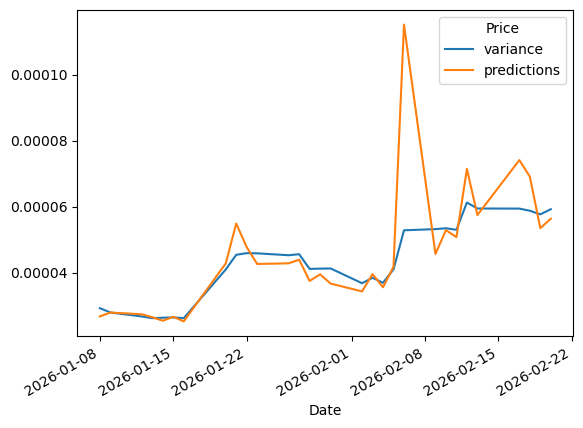

In [135]:
daily_df[['variance', 'predictions']].plot() 
#might implement signal reduction techniques to avoid the explosions

## 3. Calculate prediction premium and form a daily signal from it

- we are calculating the prediction premium. and calculate its 6 month rolling standard deviation
- from this we are creating our daily signal

In [139]:
daily_df['prediction_premium'] = (daily_df['predictions']-daily_df['variance'])/daily_df['variance']

daily_df['premium_std'] = daily_df['prediction_premium'].rolling(15).std()

<Axes: xlabel='Date'>

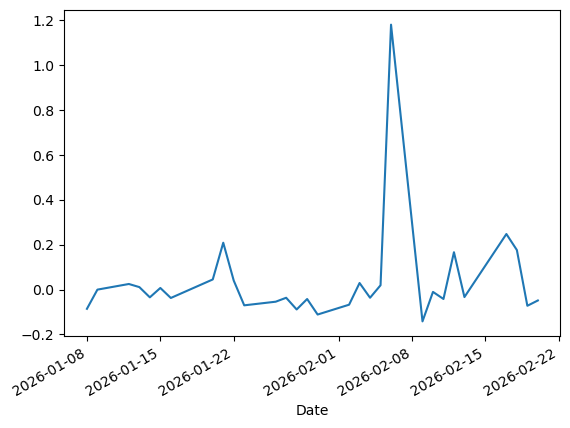

In [140]:
daily_df['prediction_premium'].plot()

<Axes: xlabel='Date'>

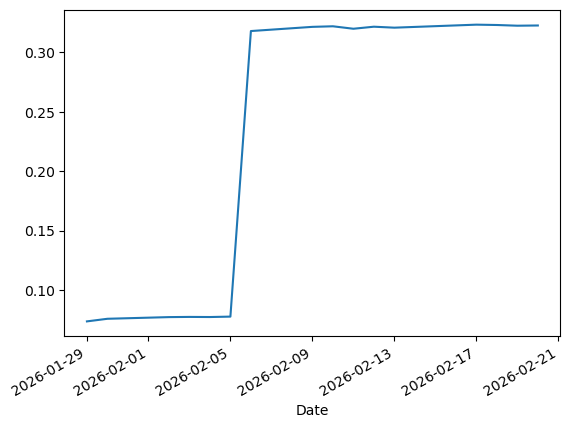

In [141]:
daily_df['premium_std'].plot()

In [142]:
daily_df['signal_daily'] = daily_df.apply(lambda x: 1 if (x['prediction_premium']>x['premium_std']*1.5)
                                         else (-1 if (x['prediction_premium']<x['premium_std']*-1.5)
                                              else np.nan),
                                         axis=1)

daily_df['signal_daily'] = daily_df['signal_daily'].shift(1)

daily_df



Price,Close,High,Low,Open,Volume,log_ret,variance,predictions,prediction_premium,premium_std,signal_daily
Date,,,,,,,,,,,
2025-11-24,666.759766,668.085864,659.640848,660.737583,80437900,NaN,NaN,NaN,NaN,NaN,NaN
2025-11-25,673.031250,674.217746,662.522264,666.660062,81077100,0.009362,NaN,NaN,NaN,NaN,NaN
2025-11-26,677.677551,679.691620,674.726250,675.633603,71879600,0.006880,NaN,NaN,NaN,NaN,NaN
2025-11-28,681.376587,681.655730,678.495087,678.854012,49212000,0.005444,NaN,NaN,NaN,NaN,NaN
2025-12-01,678.265808,680.977765,676.740287,676.810088,61201200,-0.004576,NaN,NaN,NaN,NaN,NaN
2025-12-02,679.522095,681.805326,677.328564,679.910899,62953800,0.001850,NaN,NaN,NaN,NaN,NaN
2025-12-03,681.875122,682.892076,677.687484,678.564896,57238500,0.003457,NaN,NaN,NaN,NaN,NaN
2025-12-04,682.373657,683.350750,679.332655,683.280949,61970300,0.000731,NaN,NaN,NaN,NaN,NaN
2025-12-05,683.669800,686.361857,682.563085,683.450416,79241000,0.001898,NaN,NaN,NaN,NaN,NaN


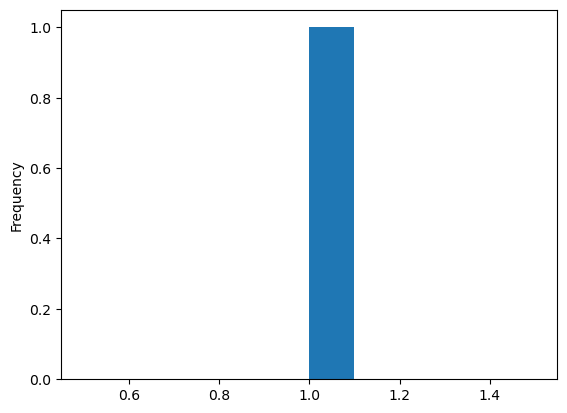

In [143]:
daily_df['signal_daily'].plot(kind='hist')

plt.show()

## 4. Merge with intraday data and calculate intraday indicators to form the intraday signal

calculate all intraday indicators and intraday signal

In [144]:
# 1. Clean daily_df
daily_data = daily_df[['signal_daily']].reset_index()
daily_data['Date'] = pd.to_datetime(daily_data['Date']) # Keep as proper datetime

# 2. Clean intraday_temp
intraday_temp = intraday_5min_df.reset_index()
# Normalize the 5-min timestamps to midnight so they match daily dates
intraday_temp['Date_Only'] = pd.to_datetime(intraday_temp['Date']).dt.normalize()

# 3. Merge
merged_df = intraday_temp.merge(daily_data, 
                               left_on='Date_Only', 
                               right_on='Date', 
                               how='left')

final_df = merged_df.set_index('Datetime')

final_df

Price,Close,High,Low,Open,Volume,Date_x,Date_Only,Date_y,signal_daily
Datetime,,,,,,,,,
2025-11-24 14:30:00+00:00,665.025818,665.070007,662.380005,662.690002,4095395,2025-11-24,2025-11-24,2025-11-24,NaN
2025-11-24 14:35:00+00:00,663.840027,665.530029,663.770020,665.039978,1747726,2025-11-24,2025-11-24,2025-11-24,NaN
2025-11-24 14:40:00+00:00,662.890015,664.380005,662.710022,663.859985,1367156,2025-11-24,2025-11-24,2025-11-24,NaN
2025-11-24 14:45:00+00:00,662.300171,663.960022,662.210022,662.880005,1127743,2025-11-24,2025-11-24,2025-11-24,NaN
2025-11-24 14:50:00+00:00,662.859985,663.663025,661.590027,662.309998,1104335,2025-11-24,2025-11-24,2025-11-24,NaN
...,...,...,...,...,...,...,...,...,...
2026-02-20 20:35:00+00:00,688.700012,688.744995,688.270020,688.460022,595695,2026-02-20,2026-02-20,2026-02-20,NaN
2026-02-20 20:40:00+00:00,689.079895,689.080017,688.565002,688.690002,862818,2026-02-20,2026-02-20,2026-02-20,NaN
2026-02-20 20:45:00+00:00,688.734985,689.119995,688.719971,689.070007,2327172,2026-02-20,2026-02-20,2026-02-20,NaN


In [146]:

final_df = final_df.drop(['Date_x', 'Date_Only', 'Date_y'], axis=1)

final_df

Price,Close,High,Low,Open,Volume,signal_daily
Datetime,,,,,,
2025-11-24 14:30:00+00:00,665.025818,665.070007,662.380005,662.690002,4095395,NaN
2025-11-24 14:35:00+00:00,663.840027,665.530029,663.770020,665.039978,1747726,NaN
2025-11-24 14:40:00+00:00,662.890015,664.380005,662.710022,663.859985,1367156,NaN
2025-11-24 14:45:00+00:00,662.300171,663.960022,662.210022,662.880005,1127743,NaN
2025-11-24 14:50:00+00:00,662.859985,663.663025,661.590027,662.309998,1104335,NaN
...,...,...,...,...,...,...
2026-02-20 20:35:00+00:00,688.700012,688.744995,688.270020,688.460022,595695,NaN
2026-02-20 20:40:00+00:00,689.079895,689.080017,688.565002,688.690002,862818,NaN
2026-02-20 20:45:00+00:00,688.734985,689.119995,688.719971,689.070007,2327172,NaN


In [147]:
import talib

In [148]:
final_df['rsi'] = talib.RSI(final_df['Close'], timeperiod=20)

upper, middle, lower = talib.BBANDS(final_df['Close'], 
                                    timeperiod=20,
                                   nbdevup=1.5,
                                   nbdevdn=1.5,
                                   matype=0)

final_df['lband'] = lower
final_df['uband'] = upper

final_df

Price,Close,High,Low,Open,Volume,signal_daily,rsi,lband,uband
Datetime,,,,,,,,,
2025-11-24 14:30:00+00:00,665.025818,665.070007,662.380005,662.690002,4095395,NaN,NaN,NaN,NaN
2025-11-24 14:35:00+00:00,663.840027,665.530029,663.770020,665.039978,1747726,NaN,NaN,NaN,NaN
2025-11-24 14:40:00+00:00,662.890015,664.380005,662.710022,663.859985,1367156,NaN,NaN,NaN,NaN
2025-11-24 14:45:00+00:00,662.300171,663.960022,662.210022,662.880005,1127743,NaN,NaN,NaN,NaN
2025-11-24 14:50:00+00:00,662.859985,663.663025,661.590027,662.309998,1104335,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...
2026-02-20 20:35:00+00:00,688.700012,688.744995,688.270020,688.460022,595695,NaN,55.157830,688.017899,689.145126
2026-02-20 20:40:00+00:00,689.079895,689.080017,688.565002,688.690002,862818,NaN,57.729352,688.056098,689.067919
2026-02-20 20:45:00+00:00,688.734985,689.119995,688.719971,689.070007,2327172,NaN,54.729779,688.069192,689.017325


In [149]:
final_df['signal_intraday'] = final_df.apply(lambda x: 1 if (x['rsi']>70)&(x['Close']>x['uband'])
                                             else (-1 if (x['rsi']<30)&(x['Close']<x['lband']) else np.nan),
                                             axis = 1)

final_df

Price,Close,High,Low,Open,Volume,signal_daily,rsi,lband,uband,signal_intraday
Datetime,,,,,,,,,,
2025-11-24 14:30:00+00:00,665.025818,665.070007,662.380005,662.690002,4095395,NaN,NaN,NaN,NaN,NaN
2025-11-24 14:35:00+00:00,663.840027,665.530029,663.770020,665.039978,1747726,NaN,NaN,NaN,NaN,NaN
2025-11-24 14:40:00+00:00,662.890015,664.380005,662.710022,663.859985,1367156,NaN,NaN,NaN,NaN,NaN
2025-11-24 14:45:00+00:00,662.300171,663.960022,662.210022,662.880005,1127743,NaN,NaN,NaN,NaN,NaN
2025-11-24 14:50:00+00:00,662.859985,663.663025,661.590027,662.309998,1104335,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...
2026-02-20 20:35:00+00:00,688.700012,688.744995,688.270020,688.460022,595695,NaN,55.157830,688.017899,689.145126,NaN
2026-02-20 20:40:00+00:00,689.079895,689.080017,688.565002,688.690002,862818,NaN,57.729352,688.056098,689.067919,NaN
2026-02-20 20:45:00+00:00,688.734985,689.119995,688.719971,689.070007,2327172,NaN,54.729779,688.069192,689.017325,NaN


<Axes: ylabel='Frequency'>

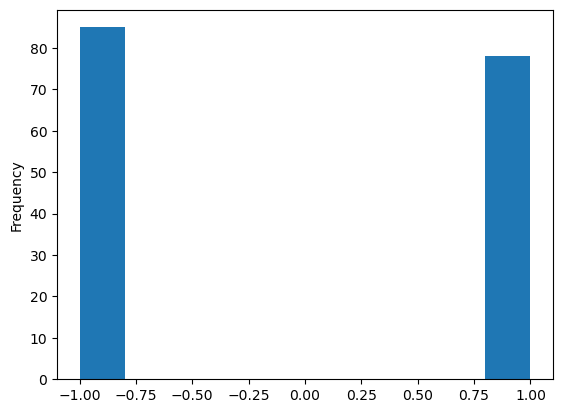

In [150]:
final_df['signal_intraday'].plot(kind='hist')

## 5. Generate the position entry and hold until the end of the day

In [187]:
#final_df['return_sign'] = final_df.apply(lambda x: -1 if (x['signal_daily']==1)&(x['signal_intraday']==1) 
#                                         else (1 if (x['signal_daily']==-1)&(x['signal_intraday']==-1) else np.nan), 
#                                         axis=1)

#final_df['return_sign'] = final_df.apply(lambda x: -1 if (x['signal_intraday']==1) 
#                                         else (1 if (x['signal_intraday']==-1) else np.nan), 
#                                         axis=1)

final_df['return_sign'] = final_df.apply(lambda x: 0 if (x['signal_intraday']==1) 
                                         else (1 if (x['signal_intraday']==-1) 
                                               else np.nan), 
                                         axis=1)

final_df['return_sign'] = final_df.groupby(pd.Grouper(freq='D'))['return_sign']\
                                    .transform(lambda x: x.ffill())

In [188]:
final_df['return'] = final_df['Close'].pct_change()

final_df['forward_return'] = final_df['return'].shift(-1)

final_df['strategy_return'] = final_df['forward_return']*final_df['return_sign']

final_df

Price,Close,High,Low,Open,Volume,signal_daily,rsi,lband,uband,signal_intraday,return_sign,return,forward_return,strategy_return,return_sign_buy,return_sign_sell
Datetime,,,,,,,,,,,,,,,,
2025-11-24 14:30:00+00:00,665.025818,665.070007,662.380005,662.690002,4095395,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.001783,NaN,NaN,NaN
2025-11-24 14:35:00+00:00,663.840027,665.530029,663.770020,665.039978,1747726,NaN,NaN,NaN,NaN,NaN,NaN,-0.001783,-0.001431,NaN,NaN,NaN
2025-11-24 14:40:00+00:00,662.890015,664.380005,662.710022,663.859985,1367156,NaN,NaN,NaN,NaN,NaN,NaN,-0.001431,-0.000890,NaN,NaN,NaN
2025-11-24 14:45:00+00:00,662.300171,663.960022,662.210022,662.880005,1127743,NaN,NaN,NaN,NaN,NaN,NaN,-0.000890,0.000845,NaN,NaN,NaN
2025-11-24 14:50:00+00:00,662.859985,663.663025,661.590027,662.309998,1104335,NaN,NaN,NaN,NaN,NaN,NaN,0.000845,0.001780,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-02-20 20:35:00+00:00,688.700012,688.744995,688.270020,688.460022,595695,NaN,55.157830,688.017899,689.145126,NaN,NaN,0.000363,0.000552,NaN,NaN,NaN
2026-02-20 20:40:00+00:00,689.079895,689.080017,688.565002,688.690002,862818,NaN,57.729352,688.056098,689.067919,NaN,NaN,0.000552,-0.000501,NaN,NaN,NaN
2026-02-20 20:45:00+00:00,688.734985,689.119995,688.719971,689.070007,2327172,NaN,54.729779,688.069192,689.017325,NaN,NaN,-0.000501,0.000138,NaN,NaN,NaN


In [189]:
daily_return_df = final_df.groupby(pd.Grouper(freq='D'))[['strategy_return']].sum()

## 6. Calculate final strategy returns

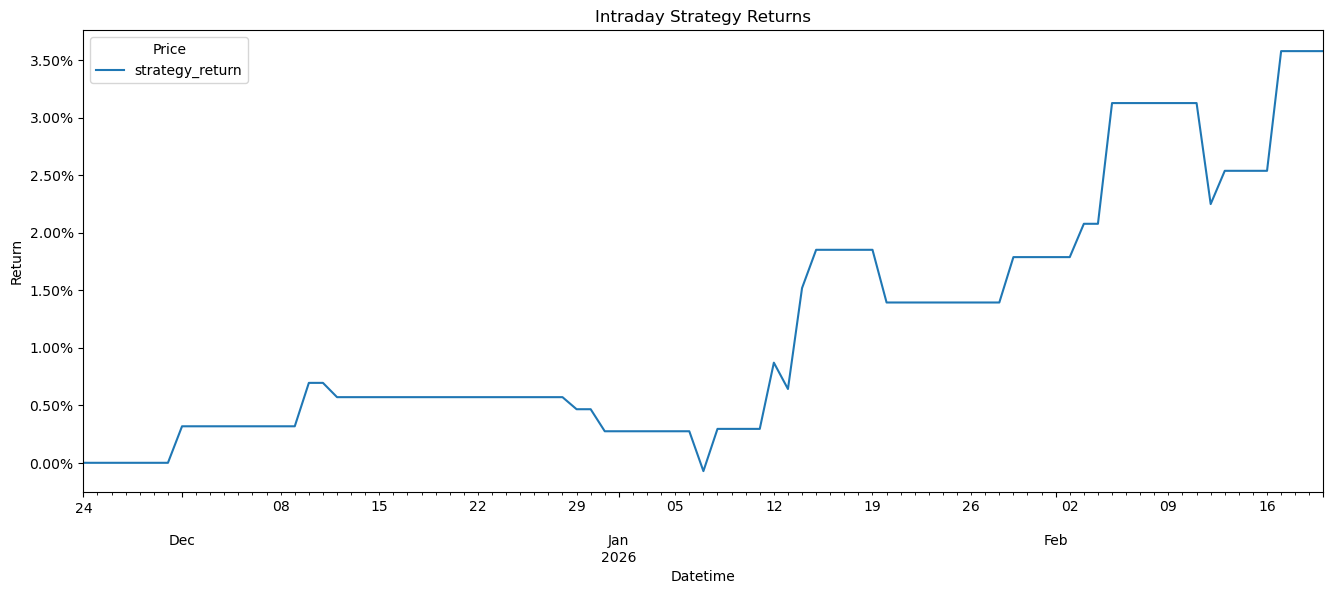

In [190]:
import matplotlib.ticker as mtick

strategy_cumulative_return = np.exp(np.log1p(daily_return_df).cumsum()).sub(1)

strategy_cumulative_return.plot(figsize=(16,6))

plt.title('Intraday Strategy Returns')

plt.gca().yaxis.set_major_formatter(mtick.PercentFormatter(1))

plt.ylabel('Return')

plt.show()